# Задача 2: Нейронные сети и анализ тональности

Выполнены все пункты уровня 1 и три бонуса уровня 2:
1. Dropout + EarlyStopping
2. Мультиклассовая классификация (3 класса)
3. Forward pass на NumPy

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [2]:
subjects = ['Сервис', 'Фильм', 'Книга', 'Приложение', 'Курс', 'Доставка', 'Отель', 'Смартфон', 'Наушники', 'Ресторан', 'Ноутбук', 'Игра']

positive_adjectives = ['отличный', 'прекрасный', 'очень хороший', 'надежный', 'удобный', 'качественный']
positive_endings = [
    'все работает стабильно и быстро',
    'оставил очень приятное впечатление',
    'полностью оправдал ожидания',
    'точно стоит своих денег',
    'хочется пользоваться снова',
    'порадовал качеством исполнения'
]

negative_adjectives = ['ужасный', 'слабый', 'очень плохой', 'разочаровывающий', 'нестабильный', 'сырой']
negative_endings = [
    'часто ломается и зависает',
    'оставил крайне неприятное впечатление',
    'совсем не оправдал ожидания',
    'явно не стоит своих денег',
    'больше не хочется использовать',
    'сделан очень некачественно'
]

neutral_adjectives = ['обычный', 'средний', 'нейтральный', 'стандартный', 'нормальный', 'без особенностей']
neutral_endings = [
    'работает без заметных плюсов и минусов',
    'не удивил, но и не разочаровал',
    'выглядит как типичный вариант',
    'в целом соответствует описанию',
    'ничем особо не выделяется',
    'оставил смешанные впечатления'
]

def synthesize_texts(adjectives, endings, n_samples):
    texts = []
    for i in range(n_samples):
        subject = subjects[i % len(subjects)]
        adjective = adjectives[i % len(adjectives)]
        ending = endings[i % len(endings)]
        texts.append(f'{subject} {adjective}, {ending}.')
    return texts

n_per_class = 60
positive_texts = synthesize_texts(positive_adjectives, positive_endings, n_per_class)
negative_texts = synthesize_texts(negative_adjectives, negative_endings, n_per_class)
neutral_texts = synthesize_texts(neutral_adjectives, neutral_endings, n_per_class)

rows = []
rows.extend([{'text': t, 'sentiment': 'positive'} for t in positive_texts])
rows.extend([{'text': t, 'sentiment': 'negative'} for t in negative_texts])
rows.extend([{'text': t, 'sentiment': 'neutral'} for t in neutral_texts])

df = pd.DataFrame(rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['class_id'] = df['sentiment'].map(label_map)

print('Размер датасета:', len(df))
display(df['sentiment'].value_counts())
display(df.head())

Размер датасета: 180


sentiment
positive    60
neutral     60
negative    60
Name: count, dtype: int64

,text,sentiment,class_id
0,"Смартфон прекрасный, оставил очень приятное вп...",positive,2
1,"Отель отличный, все работает стабильно и быстро.",positive,2
2,"Ресторан стандартный, в целом соответствует оп...",neutral,1
3,"Отель ужасный, часто ломается и зависает.",negative,0
4,"Фильм средний, не удивил, но и не разочаровал.",neutral,1


## Уровень 1: TF-IDF и бинарная классификация

Для базовой задачи берем только классы negative и positive.

In [3]:
df_binary = df[df['sentiment'].isin(['negative', 'positive'])].copy()
df_binary['target'] = (df_binary['sentiment'] == 'positive').astype('int32')

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_binary['text']).astype(np.float32).toarray()
y = df_binary['target'].values.astype('int32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

print('Форма X_train:', X_train.shape)
print('Форма X_test:', X_test.shape)
print('Баланс train:', np.bincount(y_train))
print('Баланс test:', np.bincount(y_test))

Форма X_train: (90, 122)
Форма X_test: (30, 122)
Баланс train: [45 45]
Баланс test: [15 15]


In [4]:
def evaluate_binary_model(model, X_eval, y_eval, threshold=0.5):
    y_proba = model.predict(X_eval, verbose=0).ravel()
    y_pred = (y_proba >= threshold).astype('int32')
    metrics = {
        'Accuracy': accuracy_score(y_eval, y_pred),
        'F1': f1_score(y_eval, y_pred, zero_division=0),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0)
    }
    return metrics, y_pred, y_proba

In [5]:
baseline_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_base = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=8,
    verbose=0
)

base_metrics, y_pred_base, _ = evaluate_binary_model(baseline_model, X_test, y_test)
display(pd.DataFrame([base_metrics]).round(4))
print(classification_report(y_test, y_pred_base, target_names=['negative', 'positive'], zero_division=0))

,Accuracy,F1,Precision,Recall
0,1.0,1.0,1.0,1.0


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



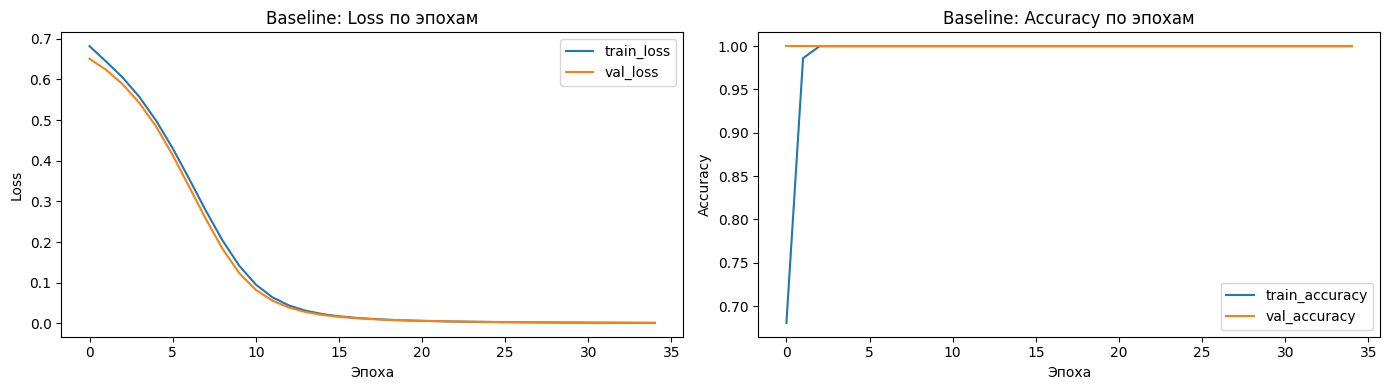

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_base.history['loss'], label='train_loss')
axes[0].plot(history_base.history['val_loss'], label='val_loss')
axes[0].set_title('Baseline: Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_base.history['accuracy'], label='train_accuracy')
axes[1].plot(history_base.history['val_accuracy'], label='val_accuracy')
axes[1].set_title('Baseline: Accuracy по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Объяснение базовой модели

- Dense(64, relu): извлекает полезные комбинации признаков TF-IDF.
- Dense(32, relu): уточняет представление перед классификацией.
- Dense(1, sigmoid): выдает вероятность положительного класса.

### Что такое loss и зачем он нужен
Loss показывает ошибку модели. Для бинарной задачи используем binary_crossentropy: чем меньше loss, тем лучше предсказания.

### Что делают fit() и predict()
- fit() обучает модель, обновляет веса и сохраняет историю метрик по эпохам.
- predict() выполняет прямой проход и возвращает предсказания для новых данных.

## Бонус 1: Dropout + EarlyStopping

Остановка на эпохе: 120


,Model,Accuracy,F1,Precision,Recall
0,Baseline,1.0,1.0,1.0,1.0
1,Dropout + EarlyStopping,1.0,1.0,1.0,1.0


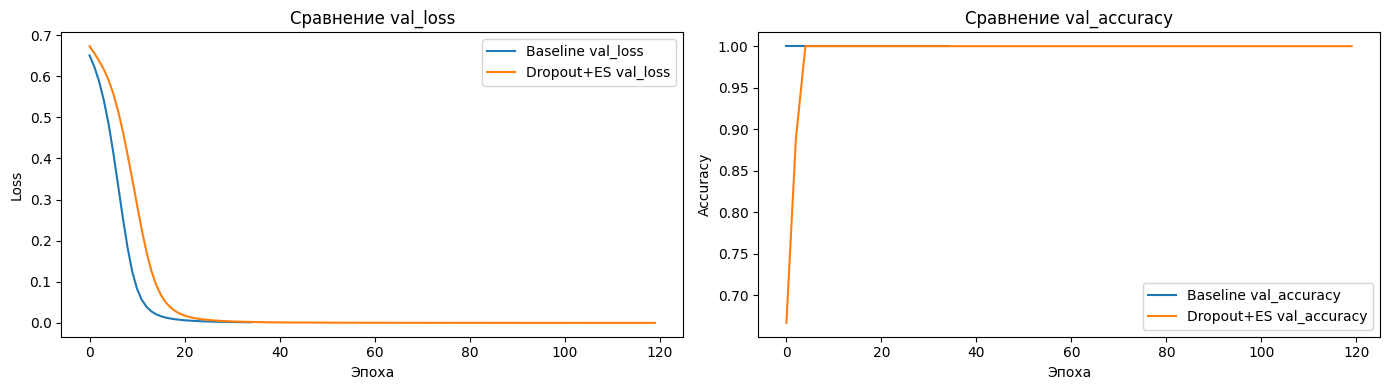

In [7]:
dropout_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.35),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history_dropout = dropout_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=120,
    batch_size=8,
    callbacks=[early_stop],
    verbose=0
)

dropout_metrics, y_pred_dropout, _ = evaluate_binary_model(dropout_model, X_test, y_test)
comparison = pd.DataFrame([
    {'Model': 'Baseline', **base_metrics},
    {'Model': 'Dropout + EarlyStopping', **dropout_metrics}
]).round(4)

print(f'Остановка на эпохе: {len(history_dropout.history["loss"])}')
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_base.history['val_loss'], label='Baseline val_loss')
axes[0].plot(history_dropout.history['val_loss'], label='Dropout+ES val_loss')
axes[0].set_title('Сравнение val_loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_base.history['val_accuracy'], label='Baseline val_accuracy')
axes[1].plot(history_dropout.history['val_accuracy'], label='Dropout+ES val_accuracy')
axes[1].set_title('Сравнение val_accuracy')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Dropout случайно отключает часть нейронов и снижает переобучение. EarlyStopping завершает обучение, когда val_loss перестает улучшаться, и возвращает лучшие веса.

## Бонус 2: мультиклассовая классификация (3 класса)

,Accuracy,F1_macro,Precision_macro,Recall_macro
0,1.0,1.0,1.0,1.0


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
     neutral       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



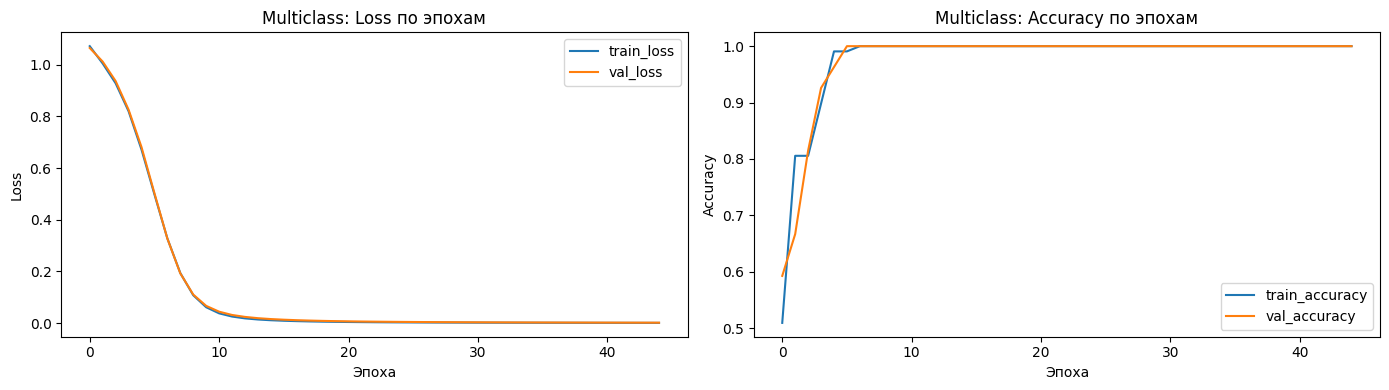

In [8]:
vectorizer_multi = TfidfVectorizer(max_features=2500, ngram_range=(1, 2))
X_all = vectorizer_multi.fit_transform(df['text']).astype(np.float32).toarray()
y_all = df['class_id'].values.astype('int32')

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_all, y_all, test_size=0.25, random_state=SEED, stratify=y_all
)

model_multi = keras.Sequential([
    layers.Input(shape=(X_train_m.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_multi.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_multi = model_multi.fit(
    X_train_m, y_train_m,
    validation_split=0.2,
    epochs=45,
    batch_size=8,
    verbose=0
)

y_pred_multi = np.argmax(model_multi.predict(X_test_m, verbose=0), axis=1)

multi_metrics = {
    'Accuracy': accuracy_score(y_test_m, y_pred_multi),
    'F1_macro': f1_score(y_test_m, y_pred_multi, average='macro', zero_division=0),
    'Precision_macro': precision_score(y_test_m, y_pred_multi, average='macro', zero_division=0),
    'Recall_macro': recall_score(y_test_m, y_pred_multi, average='macro', zero_division=0)
}

display(pd.DataFrame([multi_metrics]).round(4))
print(classification_report(y_test_m, y_pred_multi, target_names=['negative', 'neutral', 'positive'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_multi.history['loss'], label='train_loss')
axes[0].plot(history_multi.history['val_loss'], label='val_loss')
axes[0].set_title('Multiclass: Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_multi.history['accuracy'], label='train_accuracy')
axes[1].plot(history_multi.history['val_accuracy'], label='val_accuracy')
axes[1].set_title('Multiclass: Accuracy по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Softmax возвращает распределение вероятностей по 3 классам (сумма = 1), поэтому для такой постановки нужен loss sparse_categorical_crossentropy.

## Бонус 3: forward pass на NumPy

In [9]:
dense_weights = []
for layer in baseline_model.layers:
    if isinstance(layer, layers.Dense):
        W, b = layer.get_weights()
        dense_weights.append((W, b))

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_numpy(X_input, weights):
    out = X_input
    for i, (W, b) in enumerate(weights):
        out = out @ W + b
        if i < len(weights) - 1:
            out = relu(out)
        else:
            out = sigmoid(out)
    return out

y_numpy = forward_numpy(X_test.astype(np.float32), dense_weights).ravel()
y_keras = baseline_model.predict(X_test, verbose=0).ravel()

abs_diff = np.abs(y_numpy - y_keras)
print('Максимальная разница:', abs_diff.max())
print('Средняя разница:', abs_diff.mean())

display(pd.DataFrame({
    'keras_pred': y_keras[:10],
    'numpy_pred': y_numpy[:10],
    'abs_diff': abs_diff[:10]
}))

Максимальная разница: 5.9604645e-08
Средняя разница: 1.3950436e-08


,keras_pred,numpy_pred,abs_diff
0,0.000601,0.000601,0.000000e+00
1,0.001544,0.001544,1.164153e-10
2,0.998634,0.998634,0.000000e+00
3,0.001333,0.001333,0.000000e+00
4,0.998561,0.998561,5.960464e-08
5,0.001498,0.001498,1.164153e-10
6,0.998308,0.998308,5.960464e-08
7,0.998561,0.998561,5.960464e-08
8,0.002927,0.002927,2.328306e-10
9,0.000663,0.000663,5.820766e-11


## Итог и чеклист

Уровень 1 выполнен:
- TF-IDF + train/test split
- модель keras для бинарной классификации
- метрики F1, Precision, Recall
- графики loss/accuracy
- объяснение слоев, loss, fit, predict

Бонусы уровня 2:
- Dropout + EarlyStopping
- мультиклассовая классификация
- forward pass на NumPy